<a href="https://colab.research.google.com/github/rathoretina07/Deep-learning-/blob/main/RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense


In [ ]:
df = pd.read_csv('/content/allDataMean.csv')


In [ ]:
data = df[['allDataMean1']].values

In [ ]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [ ]:
# Create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 20
X, y = create_sequences(scaled_data, seq_length)


In [ ]:
# Train-test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [ ]:
# Reshape input for RNN
X_train = X_train.reshape((X_train.shape[0], seq_length, 1))
X_test = X_test.reshape((X_test.shape[0], seq_length, 1))

In [ ]:
rnn_model = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(seq_length, 1)),
    Dense(1)
])

rnn_model.compile(optimizer='adam', loss='mse')


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
history = rnn_model.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.1)

Epoch 1/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 7.3830e-05 - val_loss: 1.0497e-04
Epoch 2/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 5.3653e-05 - val_loss: 1.6305e-04
Epoch 3/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 5.4767e-05 - val_loss: 1.4723e-04
Epoch 4/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 4.7581e-05 - val_loss: 1.1170e-04
Epoch 5/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 6.8032e-05 - val_loss: 1.0593e-04
Epoch 6/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 9.0478e-05 - val_loss: 1.0289e-04
Epoch 7/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 4.7477e-05 - val_loss: 1.0262e-04
Epoch 8/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 8.3382e-05 - val_loss: 1.1104e-04
Epoch 9/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 4.9190e-05 - val_loss: 1.0277e-04
Epoch 10/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 7.9075e-05 - val_loss: 1.0051e-04
Epoch 11/50
2075/2075 ━━━━━━━━━━━━━

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate metrics
mae = mean_absolute_error(y_test_inv, y_pred_inv)
mse = mean_squared_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)

# Print results
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R² Score: {r2:.4f}")


Mean Absolute Error (MAE): 0.0103
Mean Squared Error (MSE): 0.0038
R² Score: 0.9989


In [ ]:
# Predict on test data
y_pred = rnn_model.predict(X_test)

# Inverse transform predictions and actuals
y_pred_inv = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(y_test)


1153/1153 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [ ]:
# Print a few predictions
for i in range(5):
    print(f"Actual: {y_test_inv[i][0]:.2f}, Predicted: {y_pred_inv[i][0]:.2f}")



Actual: 3.00, Predicted: 3.00
Actual: 3.00, Predicted: 3.00
Actual: 3.00, Predicted: 3.00
Actual: 3.00, Predicted: 3.00
Actual: 3.00, Predicted: 3.00


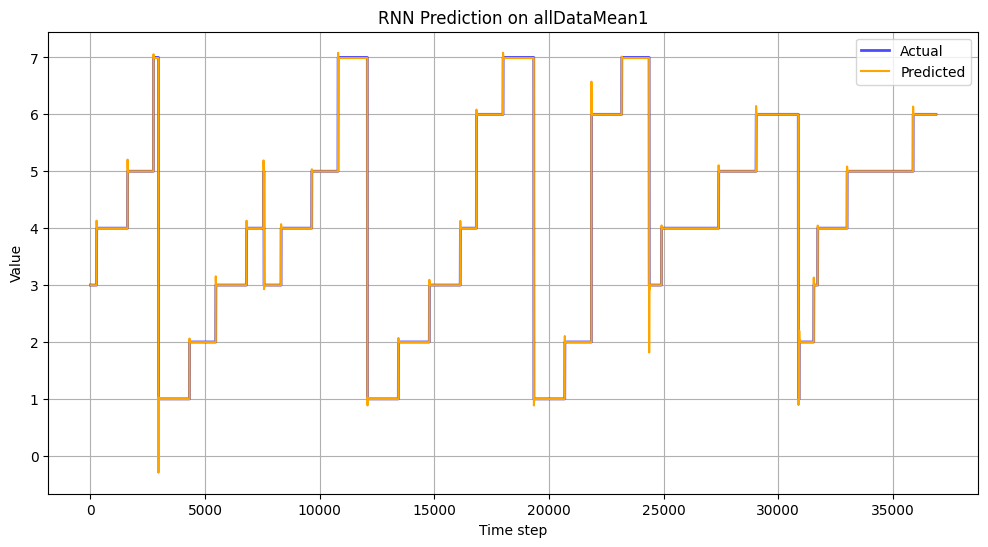

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv, label='Actual', color='blue', linewidth=2, alpha=0.7)
plt.plot(y_pred_inv, label='Predicted', color='orange', linewidth=1.5)
plt.title("RNN Prediction on allDataMean1")
plt.xlabel("Time step")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()


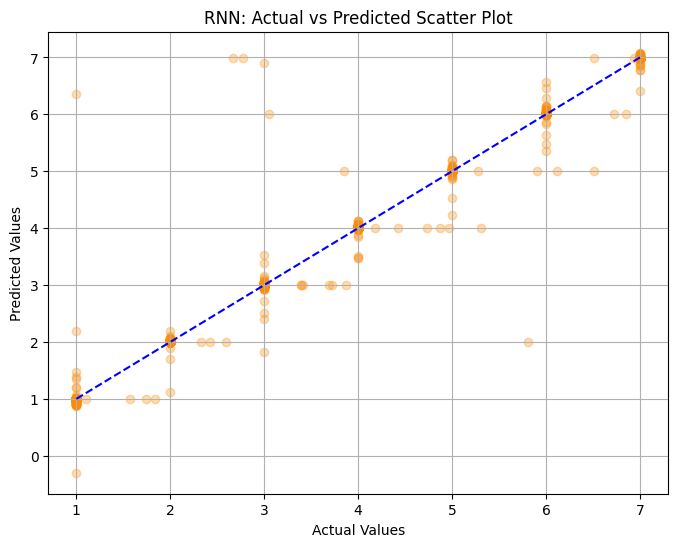

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test_inv, y_pred_inv, alpha=0.3, color='darkorange')
plt.plot([min(y_test_inv), max(y_test_inv)], [min(y_test_inv), max(y_test_inv)], color='blue', linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("RNN: Actual vs Predicted Scatter Plot")
plt.grid(True)
plt.show()


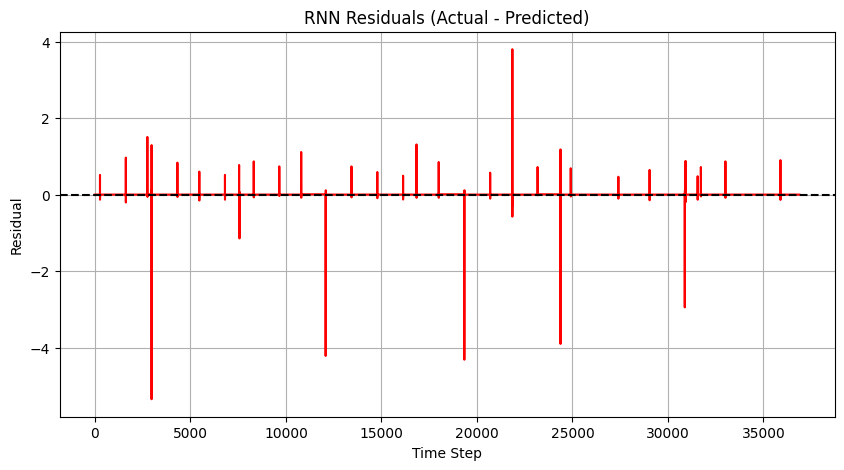

In [ ]:
residuals = y_test_inv.flatten() - y_pred_inv.flatten()

plt.figure(figsize=(10, 5))
plt.plot(residuals, color='red')
plt.title("RNN Residuals (Actual - Predicted)")
plt.xlabel("Time Step")
plt.ylabel("Residual")
plt.grid(True)
plt.axhline(0, color='black', linestyle='--')
plt.show()


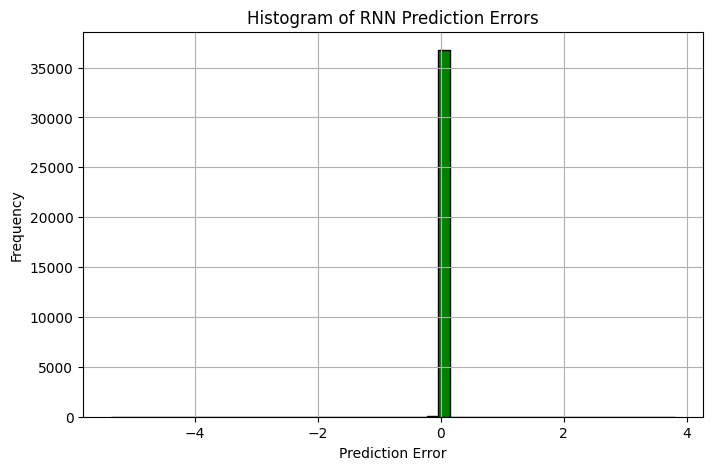

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=50, color='green', edgecolor='black')
plt.title("Histogram of RNN Prediction Errors")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


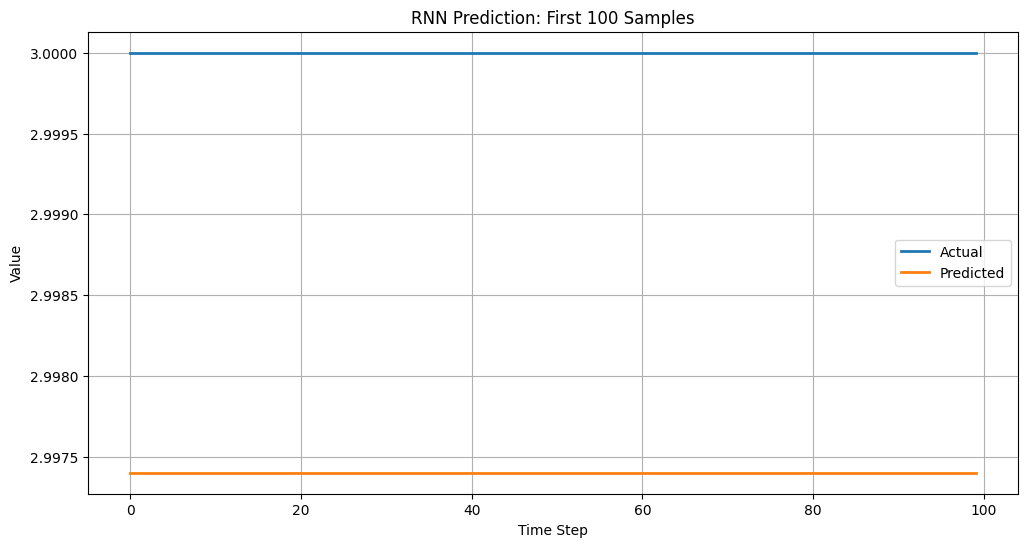

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv[:100], label='Actual', linewidth=2)
plt.plot(y_pred_inv[:100], label='Predicted', linewidth=2)
plt.title('RNN Prediction: First 100 Samples')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()
